# Validate VST Normalization

In this notebook, we will assess if the VST normalization is valid for our gene expression data set.


In [5]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


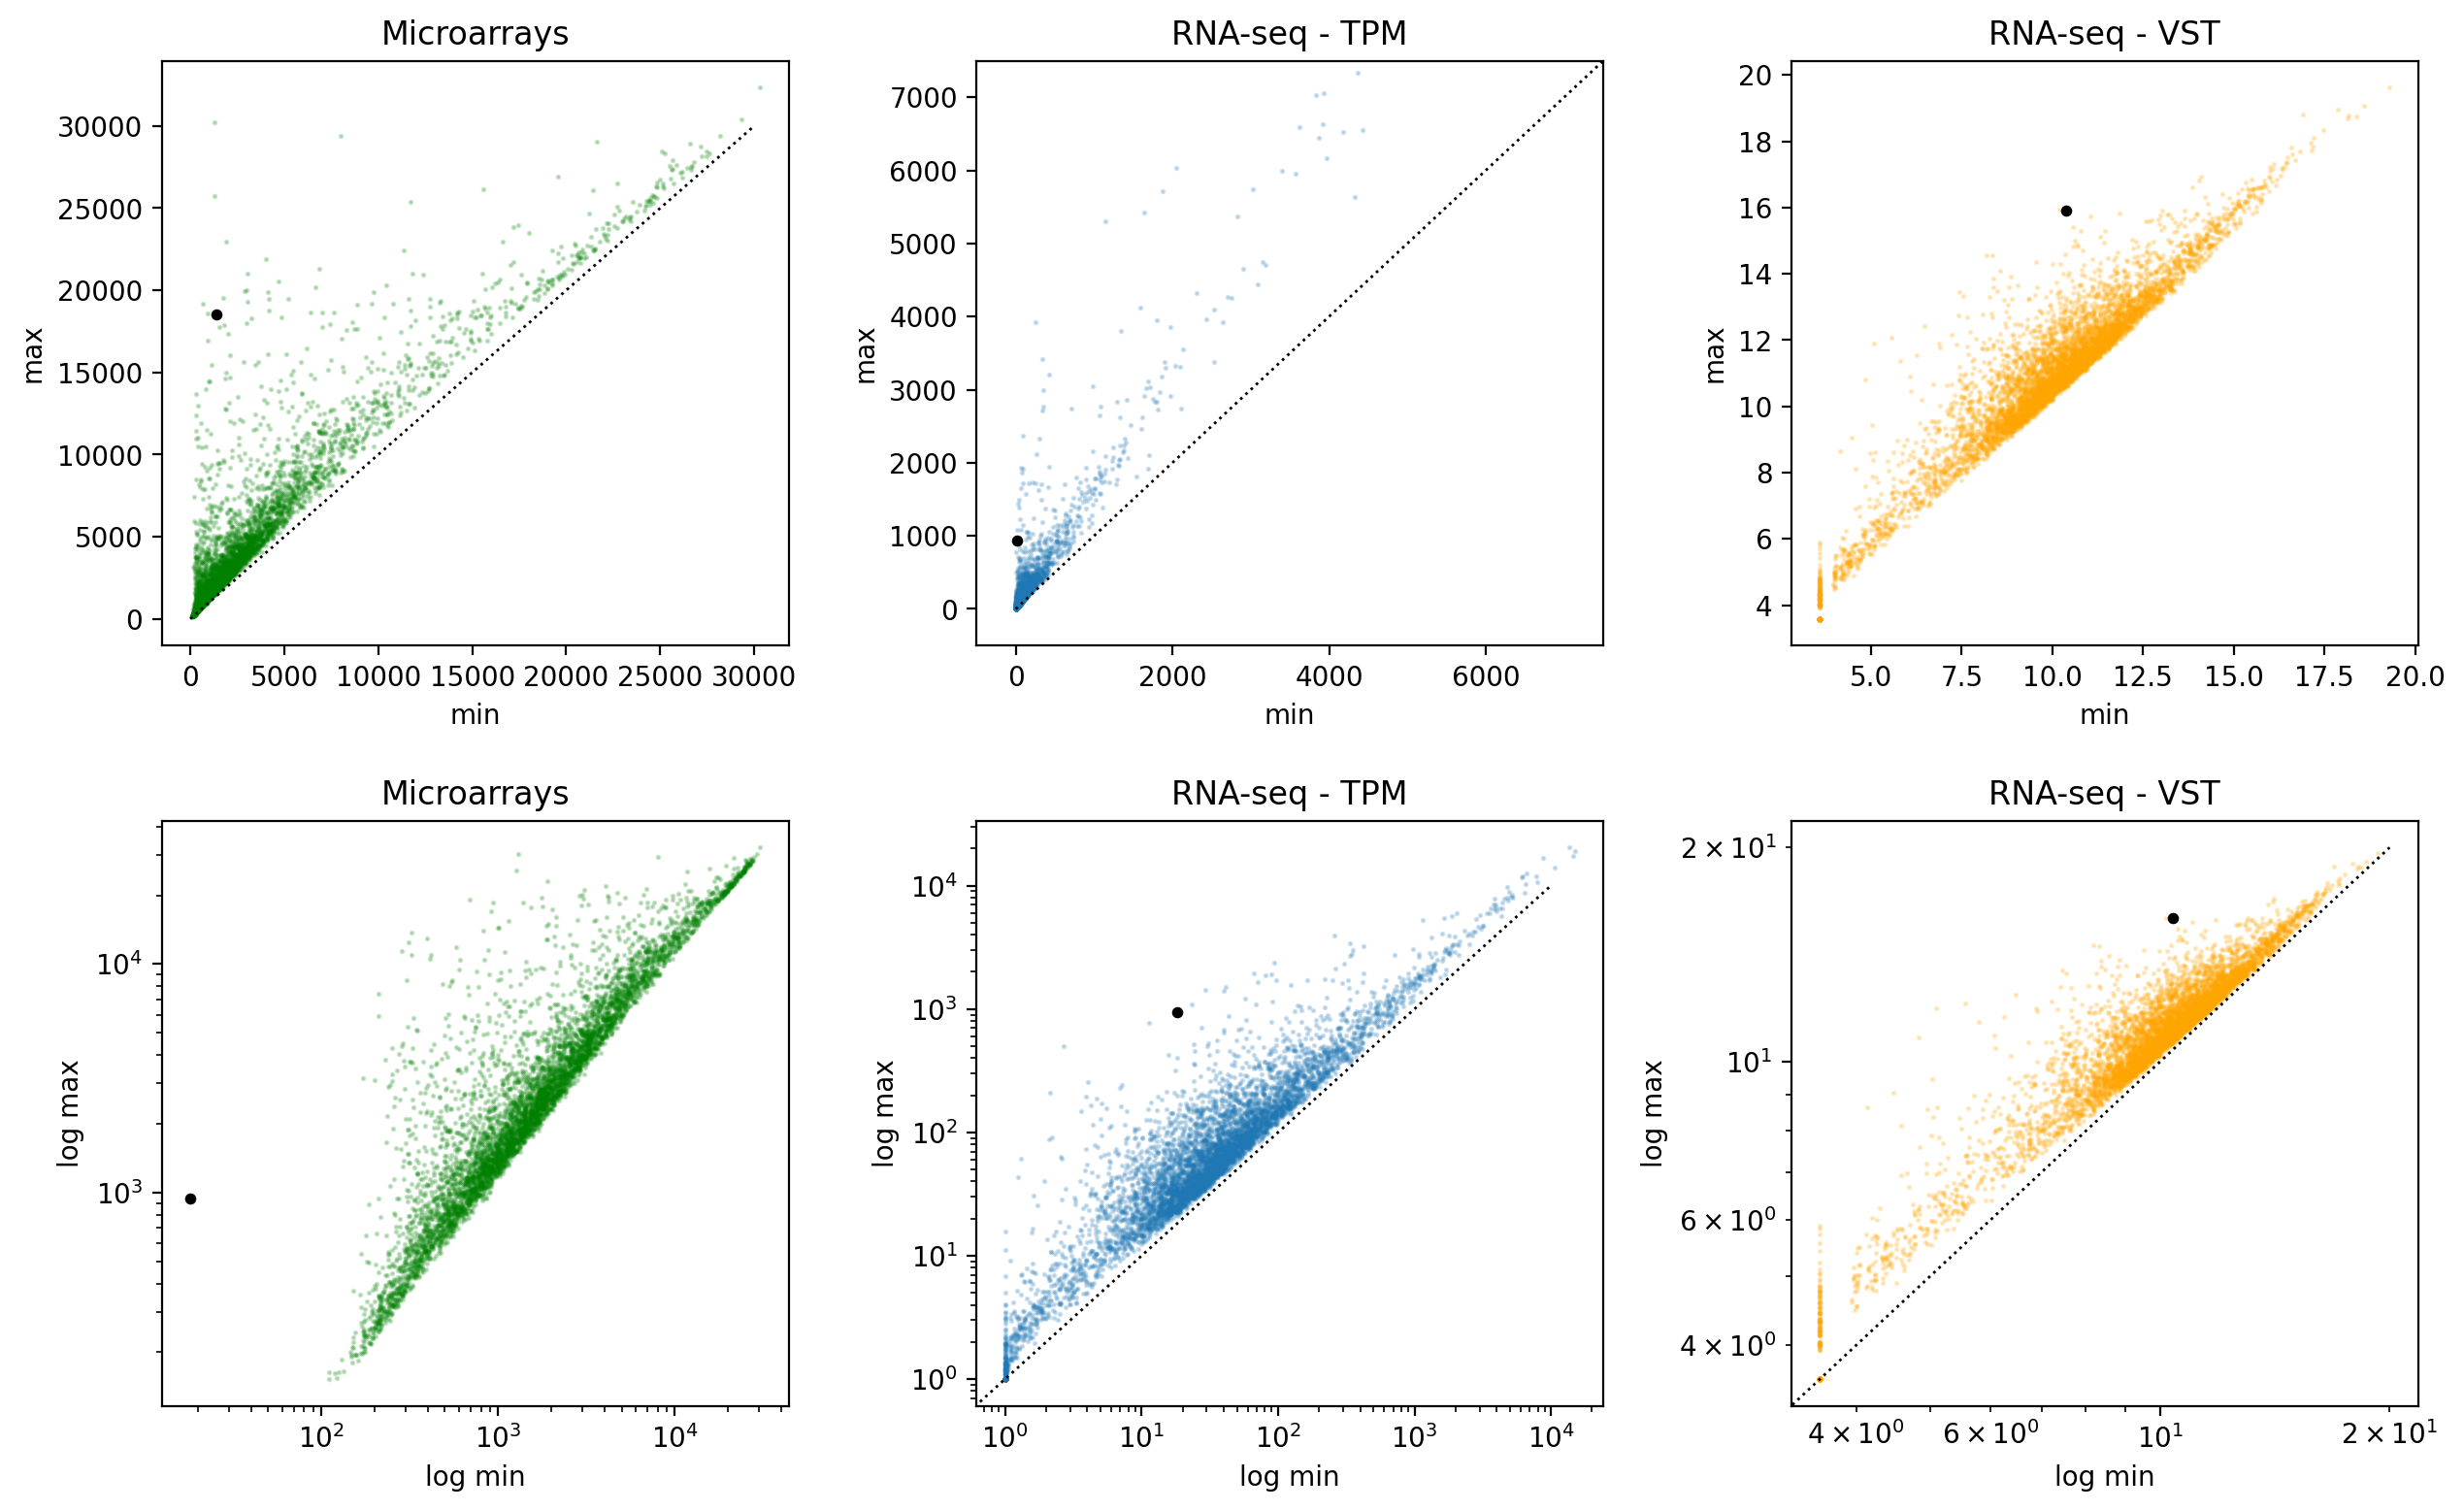

In [6]:
from src.normalization_analysis import NormAnalysis

norm_analysis = NormAnalysis()
norm_analysis.compute_meta()
norm_analysis.plot_differences()

In [27]:
tpm_values = norm_analysis.yl_rep1_TPM
vst_values = norm_analysis.yl_rep1_vst

mean_tpm = tpm_values.mean(axis=1)
mean_vst = vst_values.mean(axis=1)

Text(0.5, 1.0, 'RNA-seq Replicate 1, TPM vs VST normalization\nSpearman R=0.85, p-val=0.00')

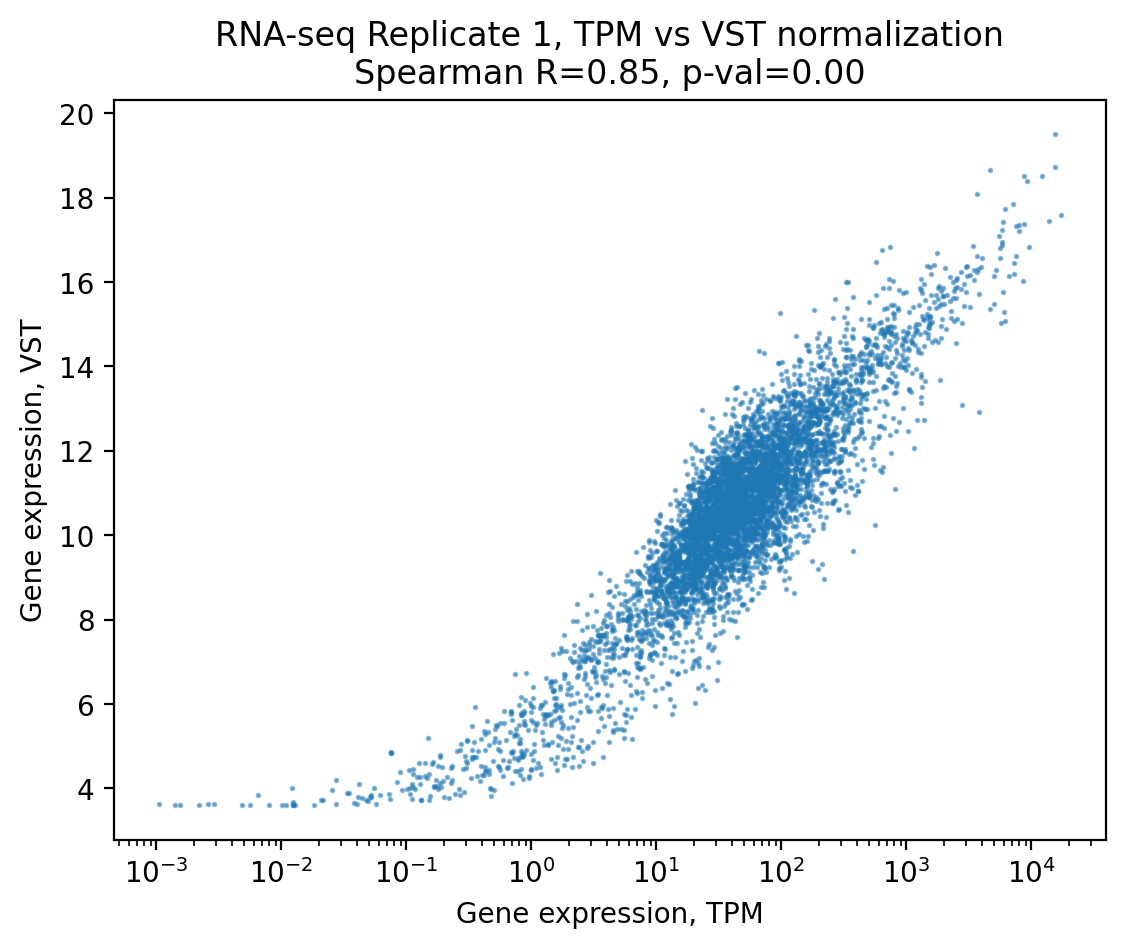

In [38]:
from scipy.stats import spearmanr

plt.scatter(mean_tpm, mean_vst, s=1, alpha=0.5)
plt.xscale('log')

spearmanrval, spearmanp = spearmanr(mean_tpm, mean_vst)
plt.ylabel("Gene expression, VST")
plt.xlabel("Gene expression, TPM")

plt.title(f"RNA-seq Replicate 1, TPM vs VST normalization\n"
          f"Spearman R={spearmanrval:.2f}, p-val={spearmanp:.2f}")

Text(0.5, 1.0, 'Original VST PTR vs Original TPM PTR\nSpearman R=0.77, p-val=0.00')

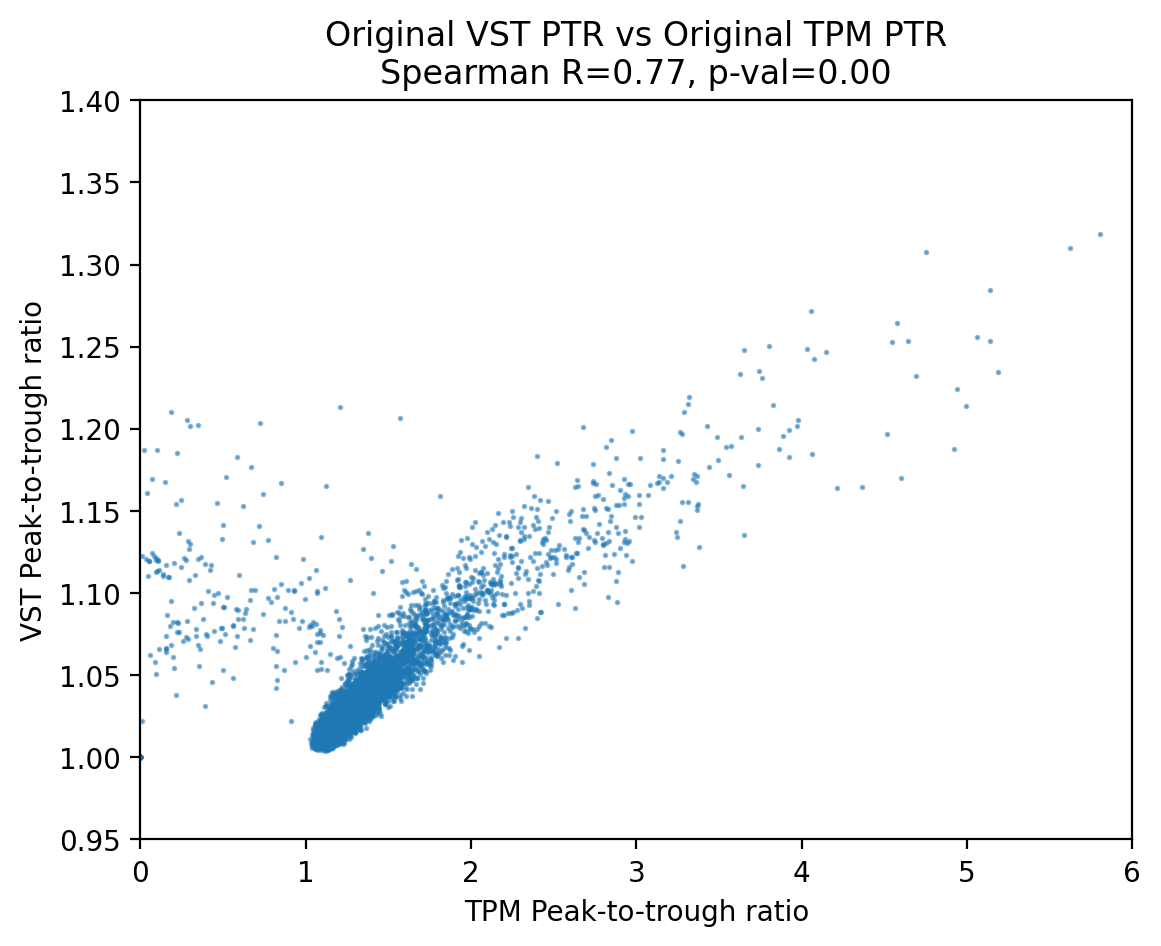

In [51]:
# Let's next check the peak to trough ratio

from cc_src.peak_to_trough import compute_80_20_ptr
vst_ptrs = vst_values.apply(compute_80_20_ptr, axis=1)
tpm_ptrs = tpm_values.apply(compute_80_20_ptr, axis=1)

plt.scatter(tpm_ptrs, vst_ptrs, alpha=0.5, s=1)
plt.xlim(0, 6)
plt.ylim(0.95, 1.4)
plt.xlabel("TPM Peak-to-trough ratio")
plt.ylabel("VST Peak-to-trough ratio")

spearmanrval, spearmanpval = spearmanr(tpm_ptrs, vst_ptrs)
plt.title(f"Original VST PTR vs Original TPM PTR\n"
          f"Spearman R={spearmanrval:.2f}, p-val={spearmanpval:.2f}")
